# Part B
##Task 1: Measure LAtency vs Batchsize

In [26]:
import torch
import time
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel

In [27]:
model = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model)
model = AutoModel.from_pretrained(model)

# Use CPU
device = torch.device("cpu")
model = model.to(device)

# Set model to evaluation mode
model.eval()

print("Model loaded successfully on CPU.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully on CPU.


In [28]:
text = "I love cats, and i love being with cats."

batch_sizes = [1, 2, 4, 8]

# Create 8 copies of the input sentence
texts = [text] * 8

inputs = tokenizer(
    texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

print("Input shape:", inputs["input_ids"].shape)

Input shape: torch.Size([8, 13])


In [29]:
results = []

for batch_size in batch_sizes:
    input_ids = inputs["input_ids"][:batch_size]
    attention_mask = inputs["attention_mask"][:batch_size]

    start = time.perf_counter()

    with torch.no_grad():
        model(input_ids=input_ids, attention_mask=attention_mask)

    total_time = time.perf_counter() - start
    time_per_sample = total_time / batch_size

    results.append((batch_size, total_time, time_per_sample))

    print(f"Batch Size: {batch_size}, "
          f"Total Time: {total_time:.4f}s, "
          f"Time/Sample: {time_per_sample:.4f}s")

Batch Size: 1, Total Time: 0.0945s, Time/Sample: 0.0945s
Batch Size: 2, Total Time: 0.1255s, Time/Sample: 0.0628s
Batch Size: 4, Total Time: 0.1904s, Time/Sample: 0.0476s
Batch Size: 8, Total Time: 0.3283s, Time/Sample: 0.0410s


In [30]:
batch_sizes = [r[0] for r in results]
total_times = [r[1] for r in results]
time_per_sample = [r[2] for r in results]

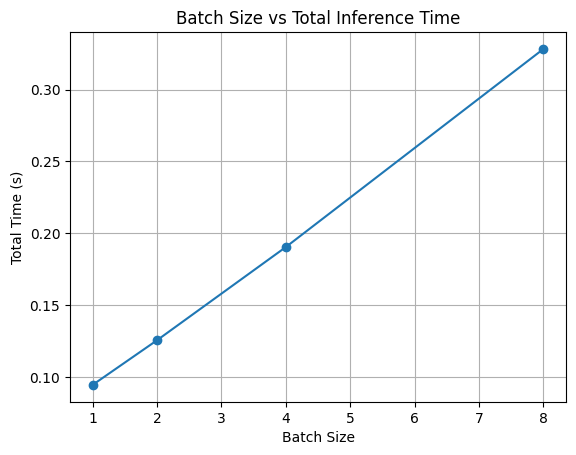

In [31]:
plt.plot(batch_sizes, total_times, marker="o")
plt.xlabel("Batch Size")
plt.ylabel("Total Time (s)")
plt.title("Batch Size vs Total Inference Time")
plt.grid()
plt.show()

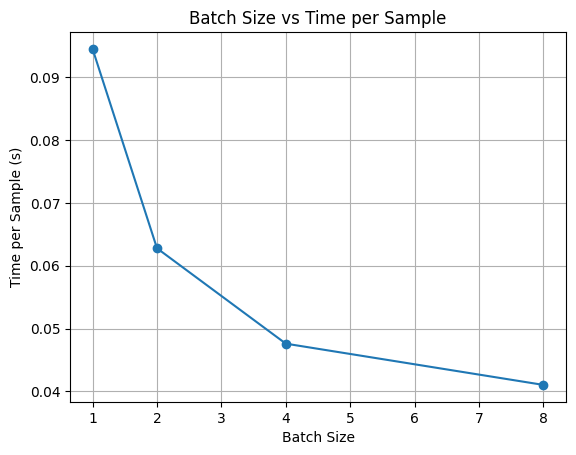

In [32]:
plt.plot(batch_sizes, time_per_sample, marker="o")
plt.xlabel("Batch Size")
plt.ylabel("Time per Sample (s)")
plt.title("Batch Size vs Time per Sample")
plt.grid()
plt.show()

As the batch size increases, the total inference time also increases because more samples are processed together. However, the time taken per sample generally decreases because the computation is shared across the batch, resulting in better CPU utilization.

##Task 2: Implement BAsic Quantization

In [33]:
quantized_model = torch.quantization.quantize_dynamic(
    model,
    {torch.nn.Linear},
    dtype=torch.qint8
)

quantized_model.eval()

print("Quantization completed.")

{torch.nn.Linear}

dtype=torch.qint8


/tmp/ipykernel_6356/3130110259.py:1: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


Quantization completed.


In [34]:
import os
import torch

torch.save(model.state_dict(), "original_model.pth")
torch.save(quantized_model.state_dict(), "quantized_model.pth")

original_size = os.path.getsize("original_model.pth") / (1024 * 1024)
quantized_size = os.path.getsize("quantized_model.pth") / (1024 * 1024)

print(f"Original model size: {original_size:.2f} MB")
print(f"Quantized model size: {quantized_size:.2f} MB")

Original model size: 253.19 MB
Quantized model size: 131.72 MB


In [35]:
input_ids = inputs["input_ids"][:4]
attention_mask = inputs["attention_mask"][:4]

start = time.perf_counter()

with torch.no_grad():
    model(input_ids=input_ids, attention_mask=attention_mask)

original_time = time.perf_counter() - start

print(f"Original model time: {original_time:.4f} s")

Original model time: 0.1248 s


In [36]:
start = time.perf_counter()

with torch.no_grad():
    quantized_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

quantized_time = time.perf_counter() - start

print(f"Quantized model time: {quantized_time:.4f} s")

Quantized model time: 0.0698 s


INT8 dynamic quantization reduces the model size because the weights of supported layers are represented using lower-precision values. The quantized model can also provide faster CPU inference, although the actual speed improvement depends on the system and model.